In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_theme(style="whitegrid")


In [8]:
#load the methylation and clinical datasets
print("Loading data...")
df_meth = pd.read_parquet('../data/processed/methylation_kirc_train.parquet')
df_clin = pd.read_csv('../data/processed/clinical_kirc_train_clustered_pca.csv')


Loading data...


In [9]:
#align the metadata
print("Aligning clinical data with methylation data...")
df_clin.set_index('sample', inplace=True)
df_clin = df_clin.reindex(df_meth.index)

#define the columns to use as labels for the plots
all_cols_to_plot = [
    'tissue_type.samples', 
    'kmeans_pca_2_k2',
    'kmeans_pca_3_k2',
    'kmeans_pca_opt_k2',
    'kmeans_raw_k2',
    'hierarchical_pca_2_k2',
    'hierarchical_pca_3_k2',
    'hierarchical_pca_opt_k2',
    'hierarchical_raw_k2',
    'gmm_pca_2_k2',
    'gmm_pca_3_k2'
]

#fill missing with 'Unknown'
for col in all_cols_to_plot:
    df_clin[col] = df_clin[col].fillna('Unknown')

Aligning clinical data with methylation data...


In [10]:
#use median imputation and scaling to prepare the methylation data for PCA and UMAP
print("Imputing missing values...")
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_meth)

print("Scaling data...")
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed) 

Imputing missing values...
Scaling data...


In [11]:
#perform PCA and UMAP on the methylation data
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X)


Running PCA...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul

Running UMAP...


/Users/matibai-tcm/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting results...


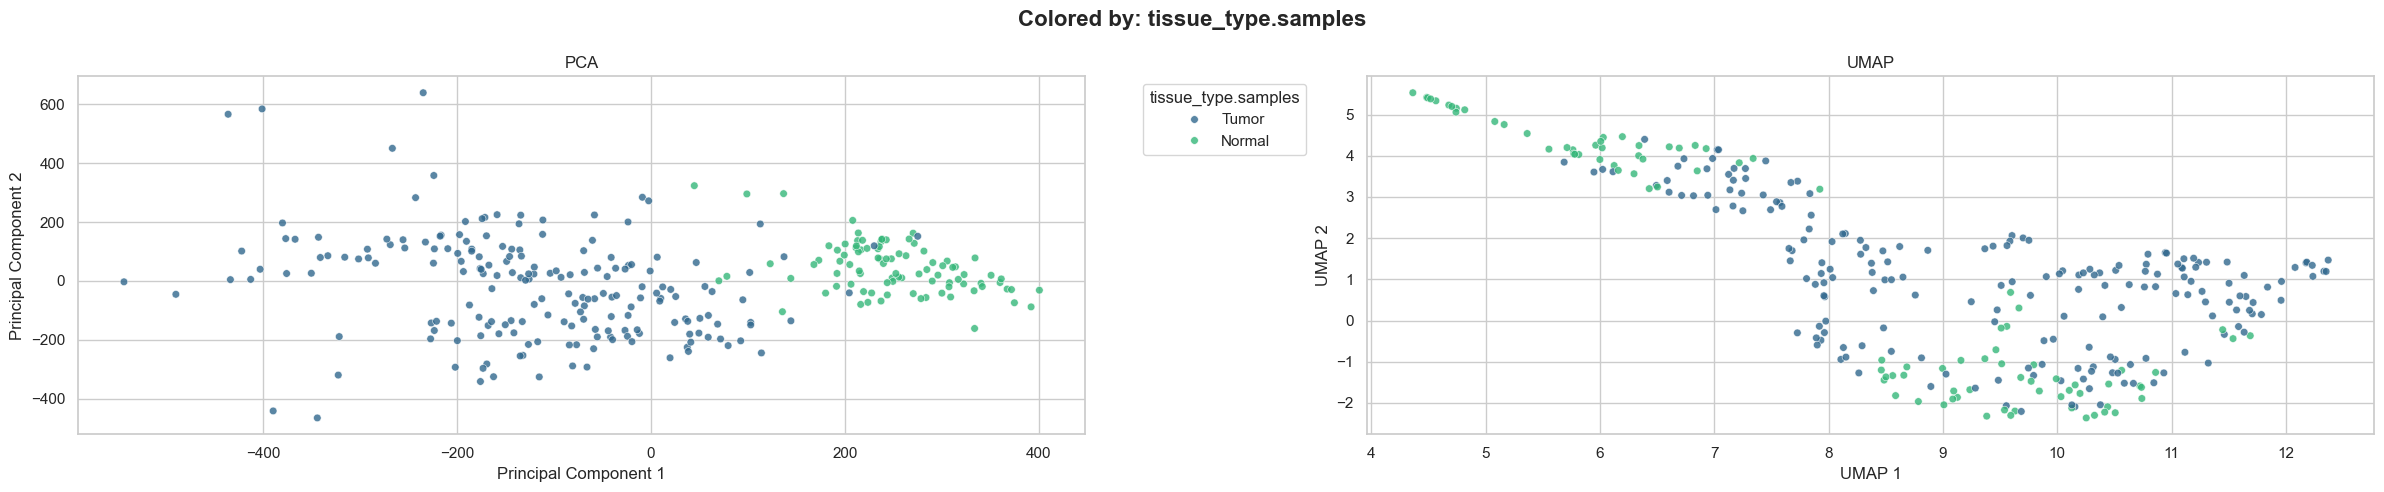

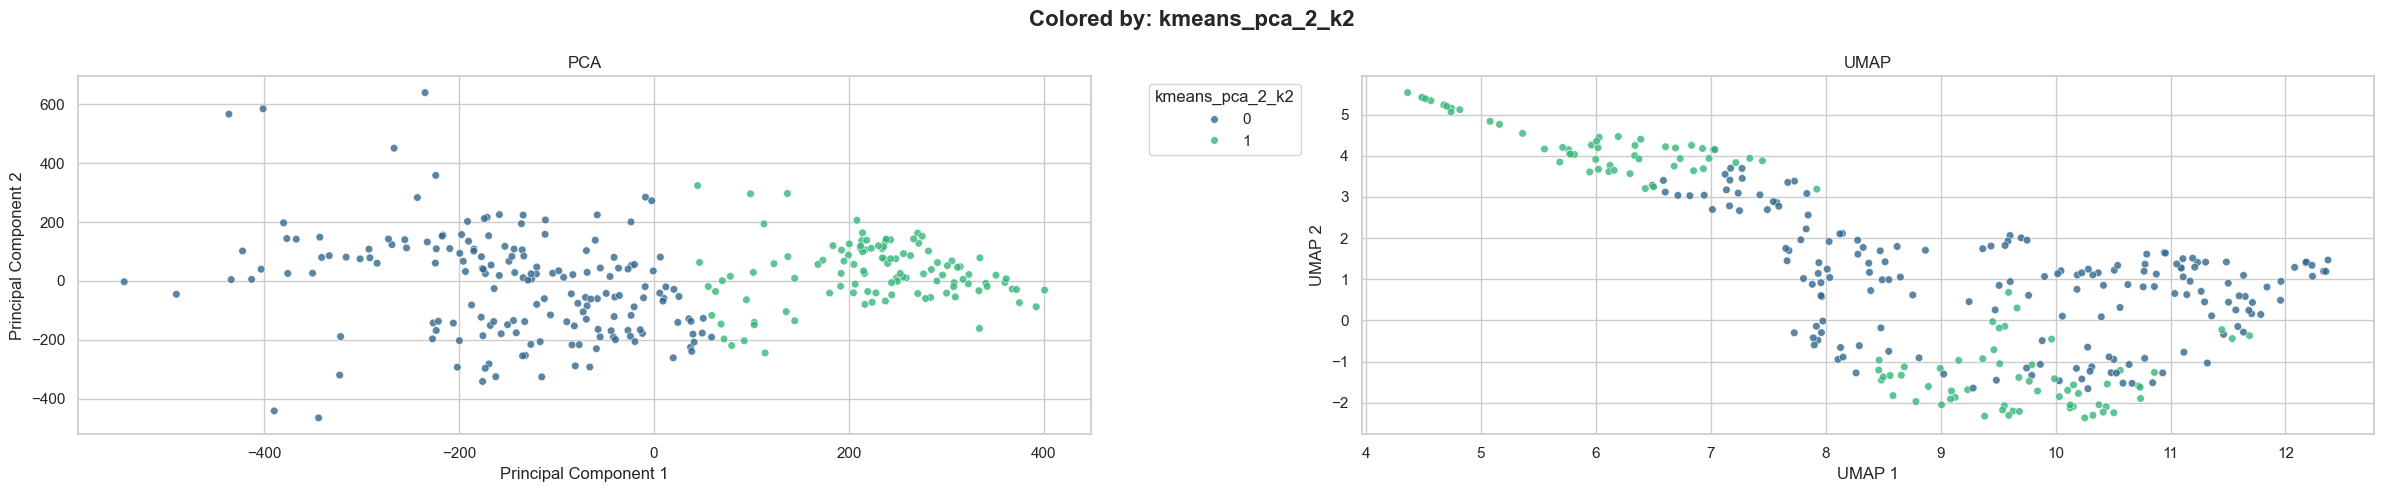

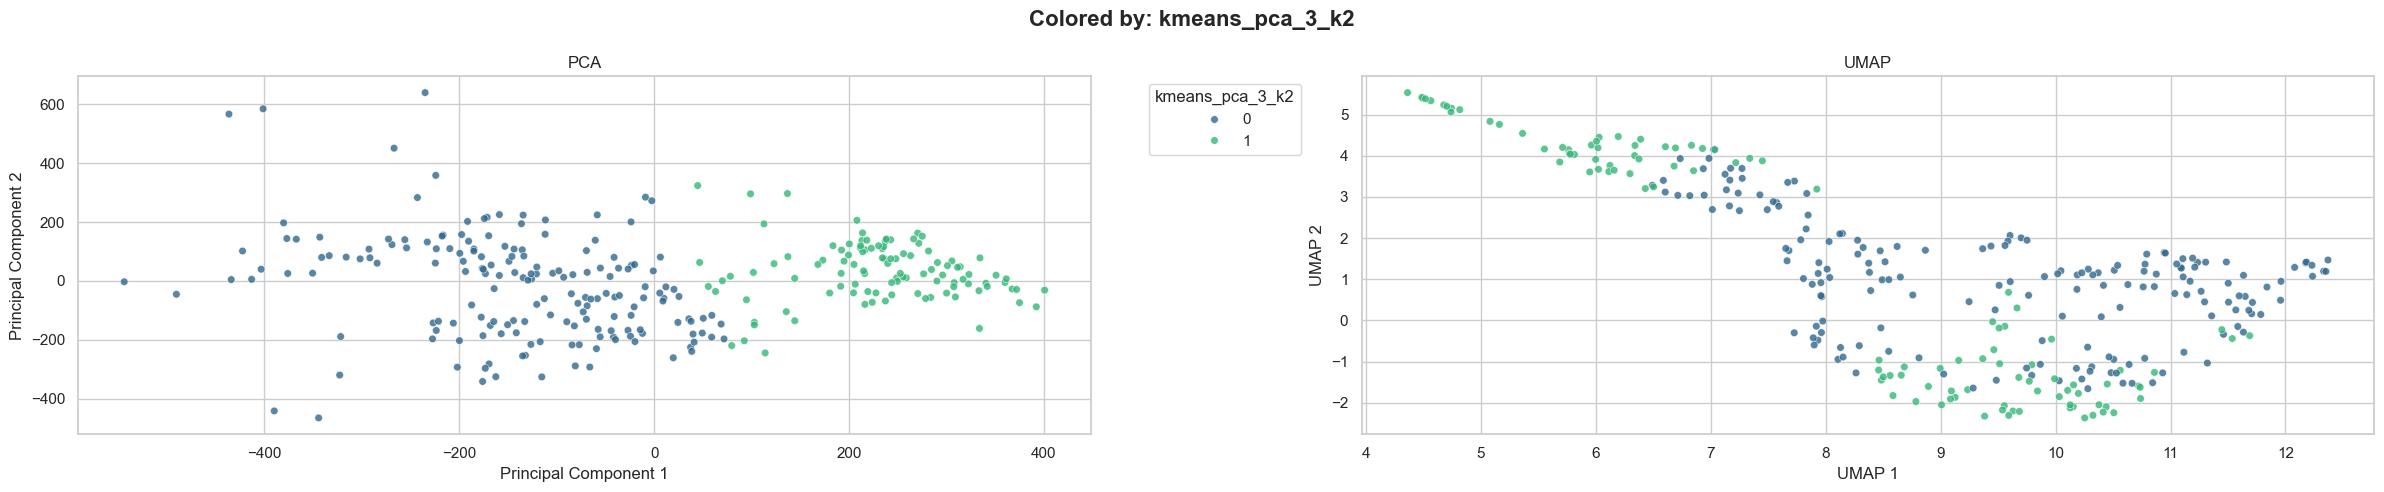

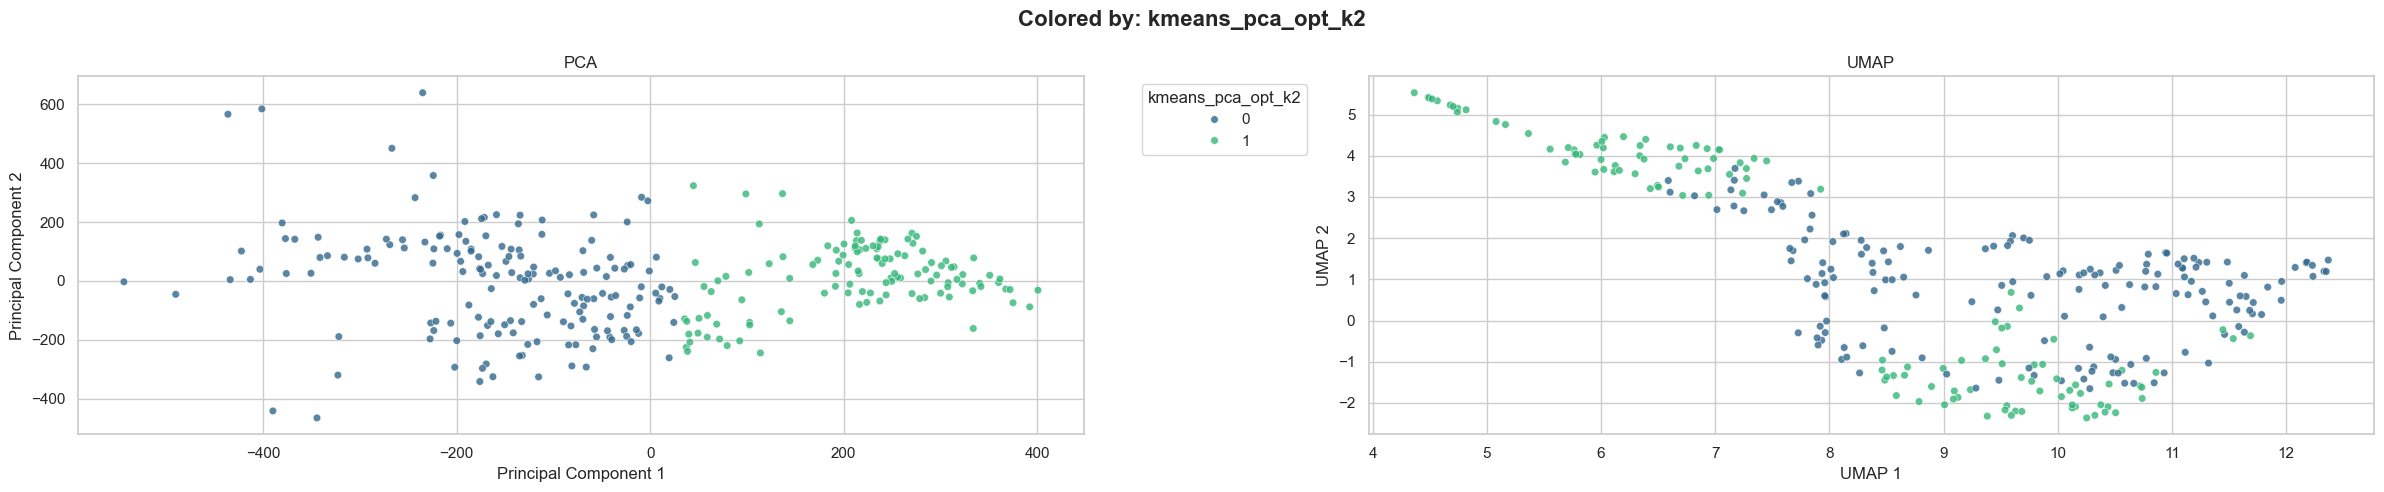

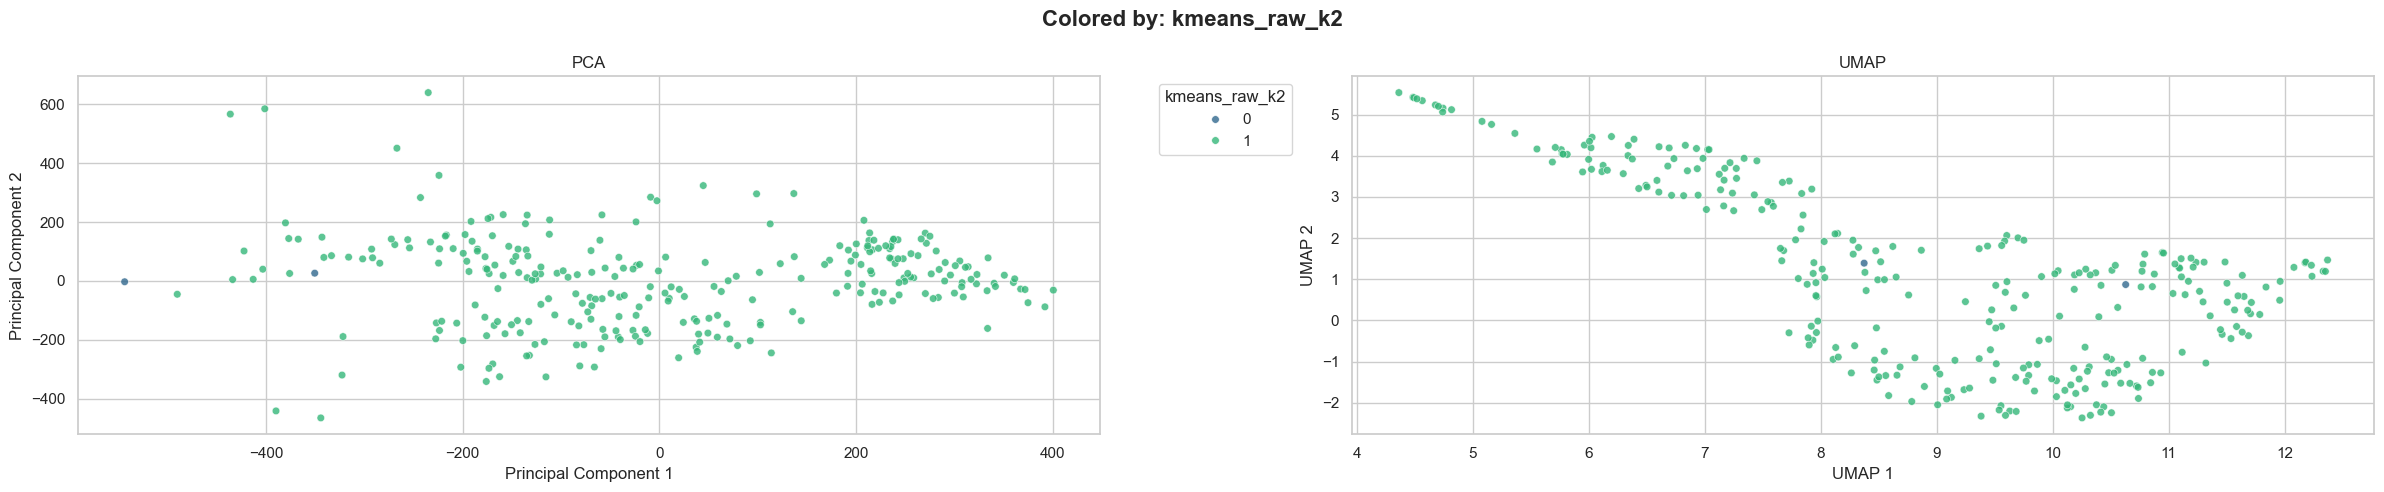

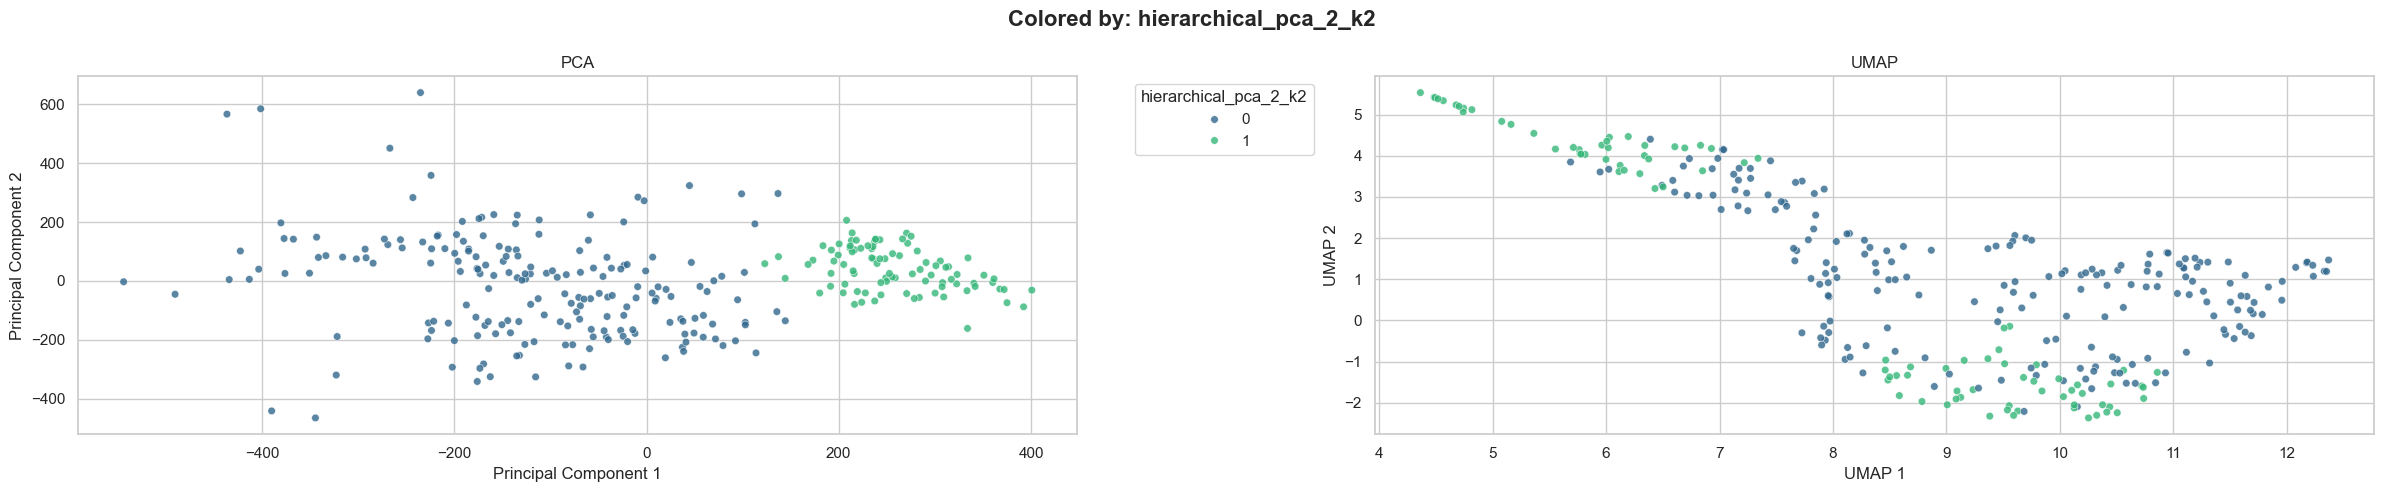

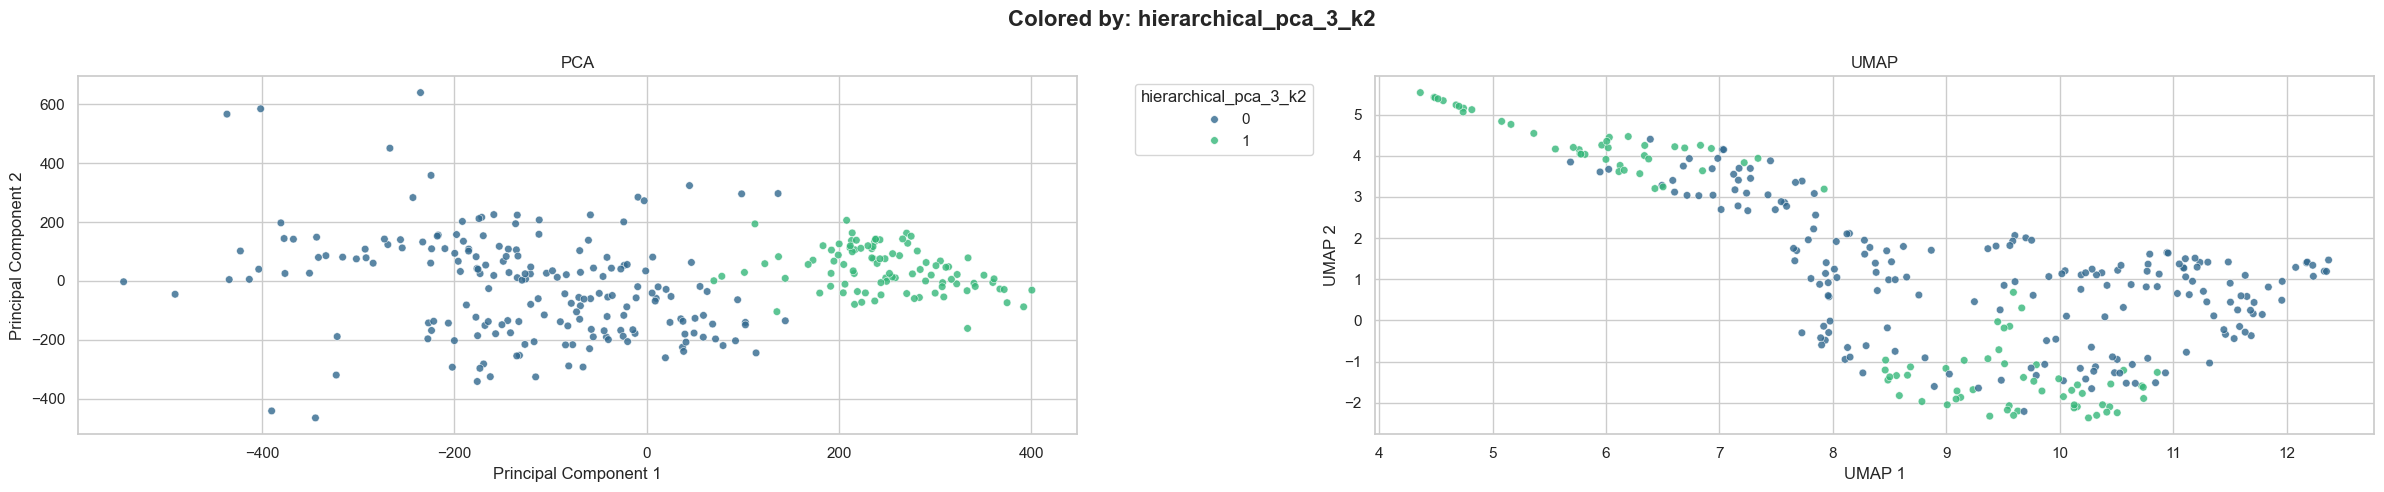

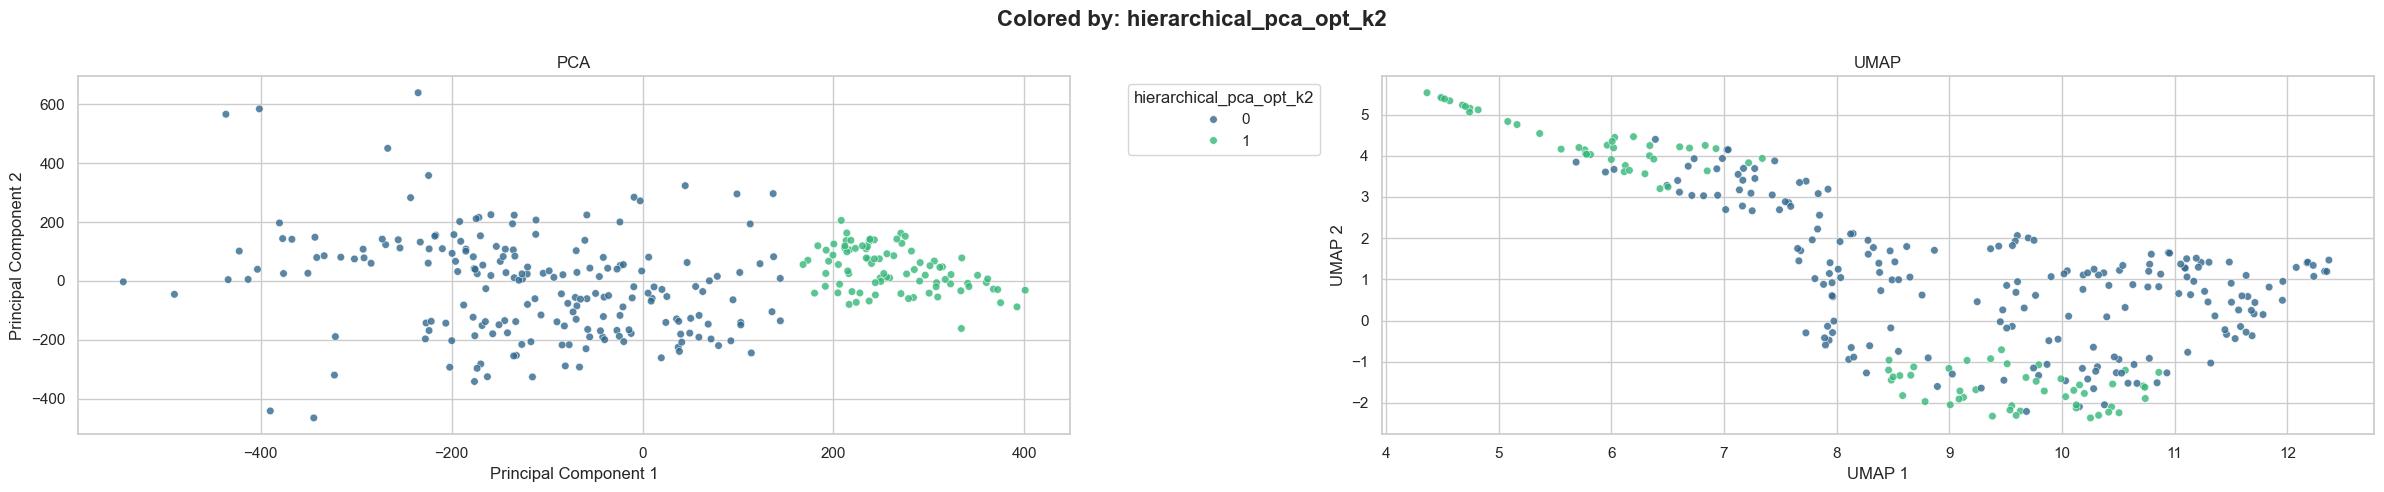

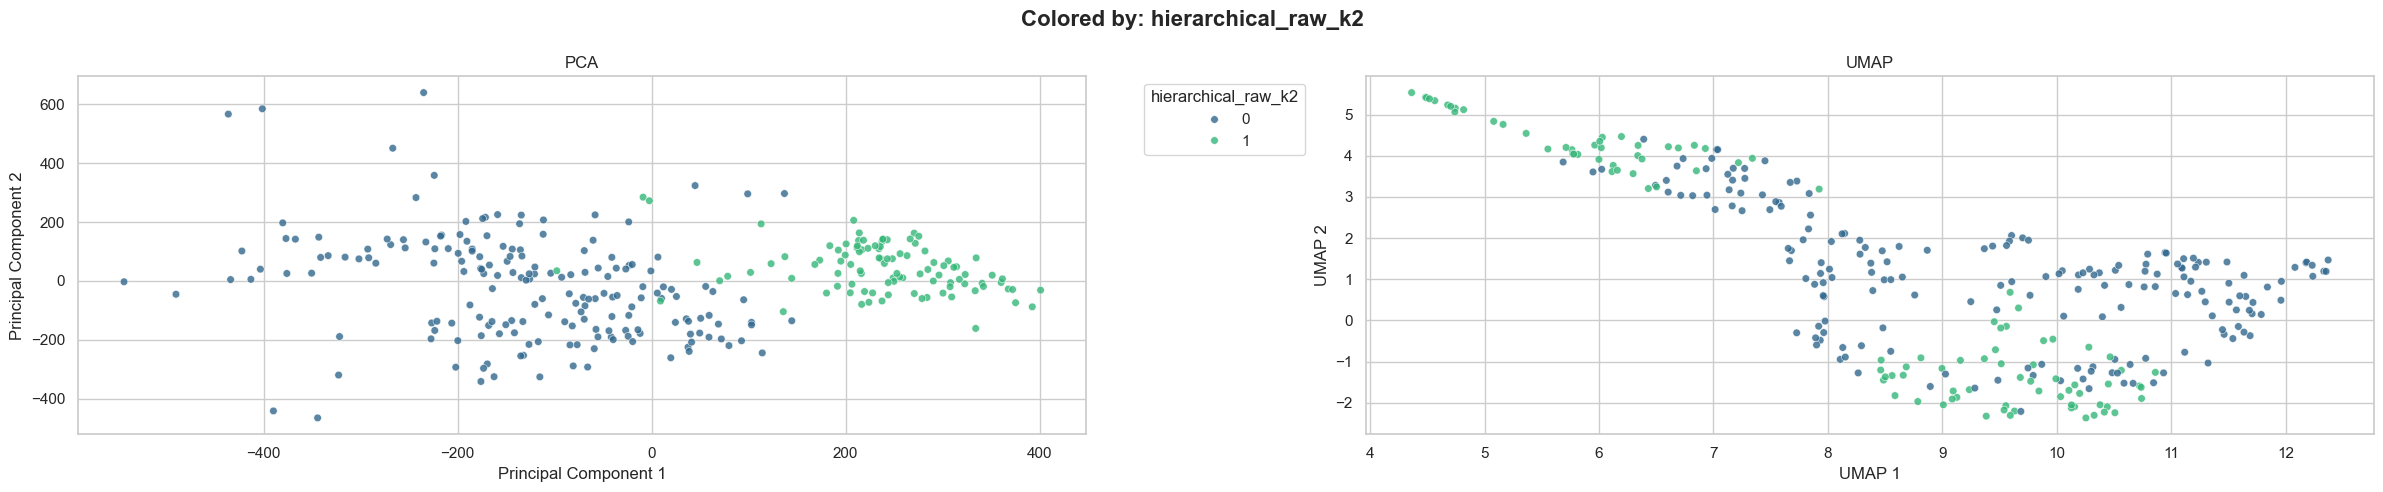

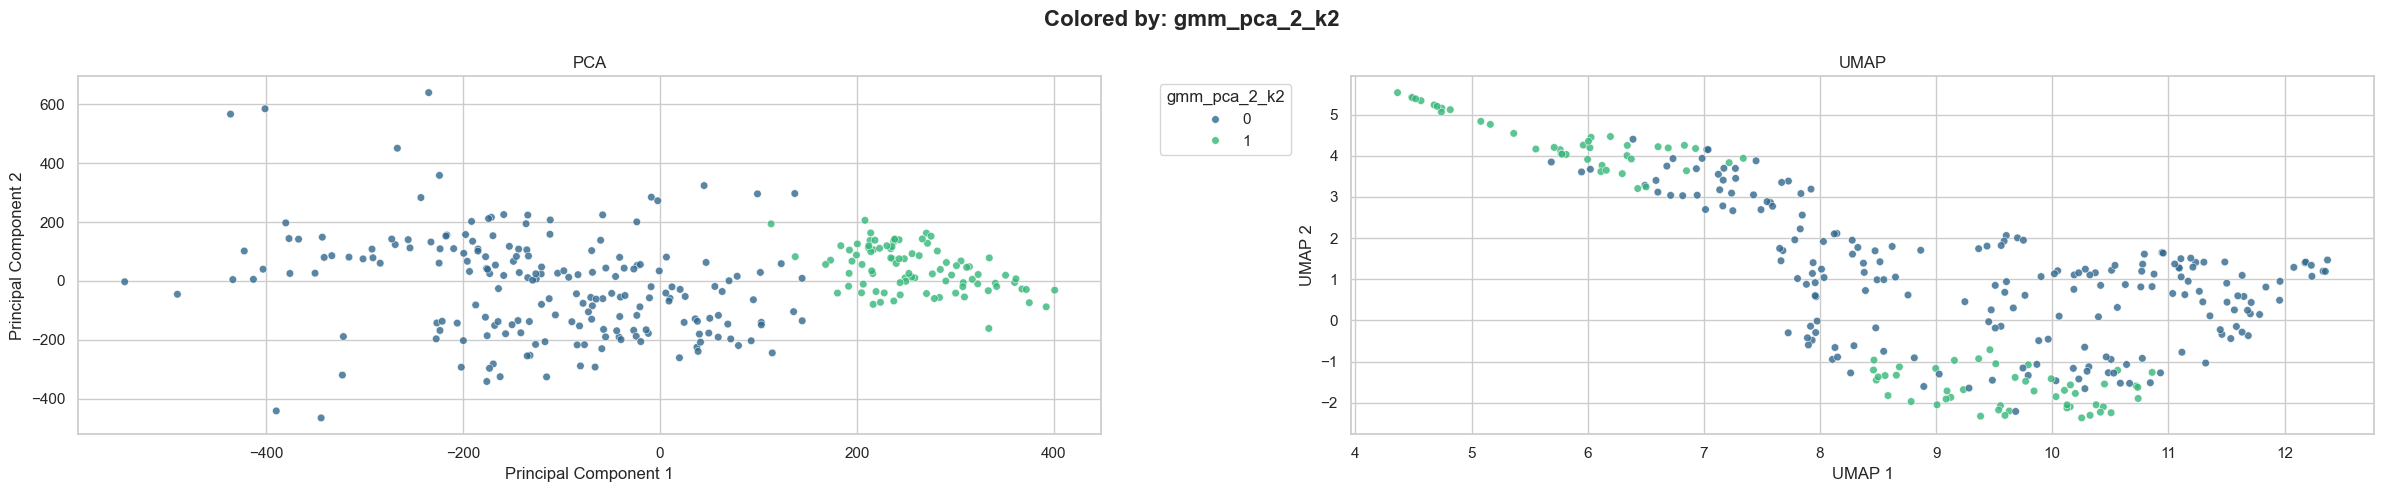

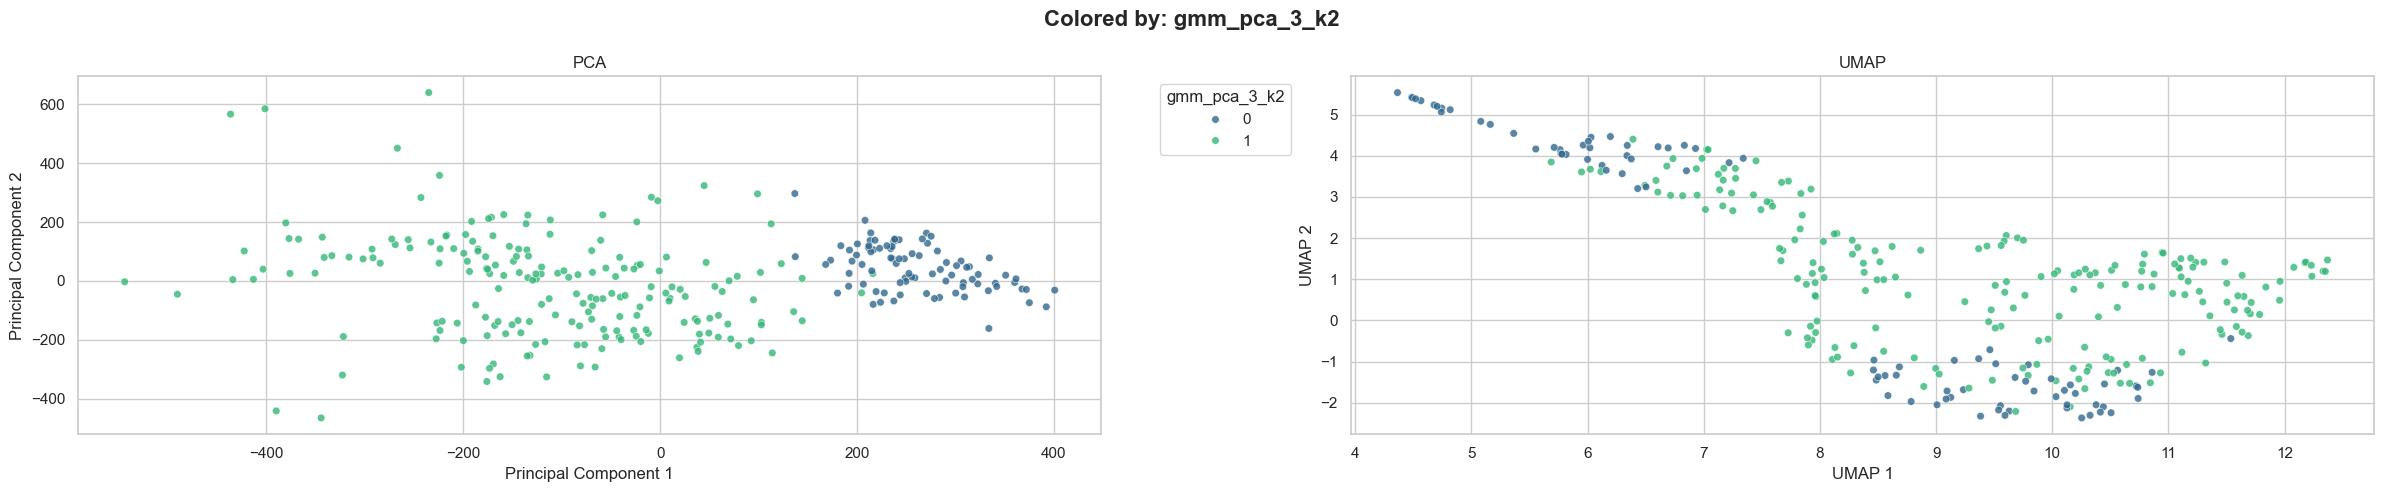

In [12]:
#visualize the results of PCA and UMAP, colored by different clinical and clustering labels
print("Plotting results...")

for col in all_cols_to_plot:
    color_labels = df_clin[col]
    
    fig, axes = plt.subplots(1, 2, figsize=(24, 5))
    fig.suptitle(f'Colored by: {col}', fontsize=16, fontweight='bold')
    
    #plot PCA
    sns.scatterplot(
        x=X_pca[:, 0], y=X_pca[:, 1], 
        hue=color_labels, palette="viridis",
        alpha=0.8, s=30, ax=axes[0]
    )
    axes[0].set_title('PCA')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    
    # Move legend outside the first plot (you could also move it to the far right)
    sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.05, 1))

    #plot UMAP
    sns.scatterplot(
        x=X_umap[:, 0], y=X_umap[:, 1], 
        hue=color_labels, palette="viridis",
        alpha=0.8, s=30, ax=axes[1], legend=False 
    )
    axes[1].set_title('UMAP')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')


    plt.tight_layout()
    plt.show()